In [41]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor


# 학습 모델 저장을 위한 라이브러리
import pickle

In [42]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [43]:
# 폰트 설정
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

### 프로젝트 셋팅

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = '/content/drive/MyDrive/은서님 파일/best_model_cd_4.dat'
# 교차검증 횟수
cv_count = 10
# 교차 검증
kfold = KFold(n_splits=cv_count, shuffle=True, random_state=1)
# 평가 결과를 담을 리스트
# 필요하다면 다른 것도 만들어주세요
f1_score_list = []
# 학습 모델 이름
model_name_list = []

### 데이터 준비
- 데이터를 읽어오고 필요한 전처리까지 다 한다음 입력데이터는 train_X, 결과데이터는 train_y라는 변수에 담아서 준비해주세요

In [46]:
plus_df = pd.read_parquet('/content/drive/MyDrive/abcde/cde추가할컬럼_df.parquet')
plus_df

,ID,기준년월,Segment,정상청구원금_B5M,이용금액_일시불_R12M,연체입금원금_B5M,연체입금원금_B2M,입회일자_신용
0,TRAIN_000000,201807,D,14958,20667,5752,398,20130101
1,TRAIN_000001,201807,E,3367,54341,821,0,20170801
2,TRAIN_000002,201807,C,23963,55656,7014,7378,20080401
3,TRAIN_000003,201807,D,19614,10753,11196,6128,20160501
4,TRAIN_000004,201807,E,0,-2129,0,272,20180601
...,...,...,...,...,...,...,...,...
2398879,TRAIN_399995,201812,E,0,0,0,0,20010701
2398880,TRAIN_399996,201812,D,23742,148106,1910,4080,20170701
2398881,TRAIN_399997,201812,C,4125,52233,856,755,20090501
2398882,TRAIN_399998,201812,E,507,0,507,0,20130101


In [47]:
plus_df = plus_df[['ID','기준년월','Segment','연체입금원금_B5M', '연체입금원금_B2M']]

In [48]:
# 데이터를 읽어온다.
train_df = pd.read_parquet('/content/drive/MyDrive/은서님 파일/Seleted(C_D)_delecteABE_all_train.parquet')
test_df = pd.read_parquet('/content/drive/MyDrive/abcde/ab_cde_test.parquet')

display(train_df)
display(test_df)

,기준년월,ID,Segment,이용금액_R3M_신용체크,_1순위카드이용금액,이용금액_R3M_신용,이용카드수_신용체크,Life_Stage,이용개월수_신용_R12M,이용개월수_신판_R12M,...,청구금액_R3M,청구금액_B0,청구서발송여부_B0,할인건수_R3M,할인건수_B0M,방문횟수_앱_R6M,방문횟수_PC_R6M,방문일수_PC_R6M,인입횟수_ARS_R6M,이용메뉴건수_ARS_R6M
0,201807,TRAIN_000000,D,196,3681,196,1,자녀성장(2),12,12,...,46588,12226,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,10회 이상,10회 이상
1,201807,TRAIN_000002,C,23988,24493,23988,1,자녀출산기,9,9,...,85931,21866,1,1회 이상,1회 이상,30회 이상,10회 이상,10회 이상,1회 이상,1회 이상
2,201807,TRAIN_000003,D,3904,5933,3904,1,자녀성장(2),12,12,...,61518,16356,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,10회 이상,10회 이상
3,201807,TRAIN_000008,C,124967,68078,121279,5,자녀출산기,12,12,...,62715,20512,1,10회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상
4,201807,TRAIN_000010,D,21001,18796,21001,1,자녀성장(1),12,12,...,30449,22512,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476827,201812,TRAIN_399979,D,31187,27337,31187,2,자녀성장(2),12,12,...,41812,11817,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상
476828,201812,TRAIN_399987,C,42492,35751,42492,1,자녀성장(2),12,12,...,68356,17859,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,10회 이상,30회 이상
476829,201812,TRAIN_399993,C,72348,27792,72348,4,자녀성장(1),12,12,...,34890,10810,1,20회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,10회 이상
476830,201812,TRAIN_399996,D,27636,26357,27636,1,자녀성장(2),12,12,...,37515,14402,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상


,기준년월,ID,남녀구분코드,연령,회원여부_이용가능,회원여부_이용가능_CA,회원여부_이용가능_카드론,소지여부_신용,소지카드수_유효_신용,소지카드수_이용가능_신용,...,잔액_신판ca최대한도소진율_r3m,변동률_일시불평잔,변동률_RV일시불평잔,변동률_할부평잔,변동률_CA평잔,변동률_RVCA평잔,변동률_카드론평잔,변동률_잔액_B1M,변동률_잔액_일시불_B1M,변동률_잔액_CA_B1M
0,201807,TEST_00000,1,40대,1,1,0,1,2,2,...,0.145300,1.463214,0.999998,0.999998,0.999998,0.999998,0.999998,0.209395,0.231043,0.0
1,201807,TEST_00001,1,60대,1,1,0,1,1,1,...,0.324844,1.315412,0.999998,1.044473,1.991974,0.999998,0.926569,-0.269161,-0.247241,0.0
2,201807,TEST_00002,1,40대,1,1,1,1,2,2,...,0.221608,1.055927,0.999998,1.053083,0.999998,0.999998,0.999998,-0.120290,0.029270,0.0
3,201807,TEST_00003,2,40대,1,1,1,1,1,1,...,0.128337,1.488069,0.999998,1.991630,0.999998,0.999998,0.999998,0.035807,-0.013359,0.0
4,201807,TEST_00004,2,40대,1,0,1,1,1,1,...,0.737263,1.208739,0.999998,1.053743,0.999998,0.999998,0.999998,-0.538740,-0.449378,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,201812,TEST_99995,2,60대,0,0,0,0,0,0,...,0.000000,0.999998,0.999998,0.999998,0.999998,0.999998,0.999998,0.000000,0.000000,0.0
599996,201812,TEST_99996,1,30대,1,1,1,1,1,1,...,0.000000,0.894539,0.999998,0.999998,0.999998,0.999998,0.999998,0.143554,0.233616,0.0
599997,201812,TEST_99997,2,30대,1,1,1,1,1,1,...,0.013292,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
599998,201812,TEST_99998,1,30대,1,1,1,1,3,3,...,0.379777,0.809328,0.999998,0.333183,0.999998,0.999998,0.999998,-0.038153,-0.106142,0.0


In [49]:
train_df = train_df.merge(plus_df, on=['ID','기준년월','Segment'], how='inner')

In [50]:
plus_cols = ['연체입금원금_B5M', '연체입금원금_B2M']

In [51]:
cols = ['이용금액_R3M_신용체크', '_1순위카드이용금액', '이용금액_R3M_신용',
       '이용카드수_신용체크', 'Life_Stage', '이용개월수_신용_R12M', '이용개월수_신판_R12M',
       '이용개월수_일시불_R12M', '이용금액_일시불_R6M', '이용금액_일시불_B0M', '이용금액_일시불_R3M',
       '이용금액_일시불_R12M', '이용개월수_신용_R6M', '이용건수_신용_R6M', '이용건수_신용_B0M',
       '이용건수_신판_R6M', '이용건수_신용_R3M', '이용건수_신판_B0M', '이용건수_일시불_R6M',
       '이용건수_신판_R3M', '이용건수_일시불_B0M', '이용개월수_신판_R6M', '이용건수_일시불_R3M',
       '이용개월수_일시불_R6M', '이용후경과월_신판', '이용건수_신용_R12M', '이용건수_신판_R12M',
       '이용건수_일시불_R12M', '이용가맹점수', '이용후경과월_신용', '이용금액_오프라인_B0M',
       '이용금액_오프라인_R3M', '이용건수_오프라인_B0M', '_3순위업종_이용금액', '_3순위쇼핑업종_이용금액',
       '_2순위업종_이용금액', '이용개월수_오프라인_R6M', '이용금액_오프라인_R6M', '_2순위쇼핑업종_이용금액',
       '정상청구원금_B5M', '정상청구원금_B2M', '연속유실적개월수_기본_24M_카드', '정상청구원금_B0M',
       '정상입금원금_B0M', '정상입금원금_B5M', '정상입금원금_B2M', '이용개월수_전체_R6M',
       '이용개월수_전체_R3M', '청구금액_R6M', '청구금액_R3M', '청구금액_B0', '청구서발송여부_B0',
       '할인건수_R3M', '할인건수_B0M', '방문횟수_앱_R6M', '방문횟수_PC_R6M', '방문일수_PC_R6M',
       '인입횟수_ARS_R6M', '이용메뉴건수_ARS_R6M']

In [52]:
train_df.columns

Index(['기준년월', 'ID', 'Segment', '이용금액_R3M_신용체크', '_1순위카드이용금액', '이용금액_R3M_신용',
       '이용카드수_신용체크', 'Life_Stage', '이용개월수_신용_R12M', '이용개월수_신판_R12M',
       '이용개월수_일시불_R12M', '이용금액_일시불_R6M', '이용금액_일시불_B0M', '이용금액_일시불_R3M',
       '이용금액_일시불_R12M', '이용개월수_신용_R6M', '이용건수_신용_R6M', '이용건수_신용_B0M',
       '이용건수_신판_R6M', '이용건수_신용_R3M', '이용건수_신판_B0M', '이용건수_일시불_R6M',
       '이용건수_신판_R3M', '이용건수_일시불_B0M', '이용개월수_신판_R6M', '이용건수_일시불_R3M',
       '이용개월수_일시불_R6M', '이용후경과월_신판', '이용건수_신용_R12M', '이용건수_신판_R12M',
       '이용건수_일시불_R12M', '이용가맹점수', '이용후경과월_신용', '이용금액_오프라인_B0M',
       '이용금액_오프라인_R3M', '이용건수_오프라인_B0M', '_3순위업종_이용금액', '_3순위쇼핑업종_이용금액',
       '_2순위업종_이용금액', '이용개월수_오프라인_R6M', '이용금액_오프라인_R6M', '_2순위쇼핑업종_이용금액',
       '정상청구원금_B5M', '정상청구원금_B2M', '연속유실적개월수_기본_24M_카드', '정상청구원금_B0M',
       '정상입금원금_B0M', '정상입금원금_B5M', '정상입금원금_B2M', '이용개월수_전체_R6M',
       '이용개월수_전체_R3M', '청구금액_R6M', '청구금액_R3M', '청구금액_B0', '청구서발송여부_B0',
       '할인건수_R3M', '할인건수_B0M', '방문횟수_앱_R6M', '방문횟수_PC_R6M', '방문일수_PC_R6M',
       '인

In [53]:
colnames = plus_cols + cols

In [54]:
train_df = train_df[colnames]

In [55]:
 test_df = test_df[colnames]

In [56]:
# 데이터 프레임을 합친다.
all_df = pd.concat([train_df, test_df])
all_df.reset_index(inplace=True, drop=True)
all_df

,연체입금원금_B5M,연체입금원금_B2M,이용금액_R3M_신용체크,_1순위카드이용금액,이용금액_R3M_신용,이용카드수_신용체크,Life_Stage,이용개월수_신용_R12M,이용개월수_신판_R12M,이용개월수_일시불_R12M,...,청구금액_R3M,청구금액_B0,청구서발송여부_B0,할인건수_R3M,할인건수_B0M,방문횟수_앱_R6M,방문횟수_PC_R6M,방문일수_PC_R6M,인입횟수_ARS_R6M,이용메뉴건수_ARS_R6M
0,5752,398,196,3681,196,1,자녀성장(2),12,12,12,...,46588,12226,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,10회 이상,10회 이상
1,7014,7378,23988,24493,23988,1,자녀출산기,9,9,9,...,85931,21866,1,1회 이상,1회 이상,30회 이상,10회 이상,10회 이상,1회 이상,1회 이상
2,11196,6128,3904,5933,3904,1,자녀성장(2),12,12,7,...,61518,16356,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,10회 이상,10회 이상
3,9762,13192,124967,68078,121279,5,자녀출산기,12,12,12,...,62715,20512,1,10회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상
4,2782,947,21001,18796,21001,1,자녀성장(1),12,12,12,...,30449,22512,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1076827,0,0,0,0,0,0,노년생활,0,0,0,...,0,0,0,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상
1076828,689,0,3110,1231,3110,1,자녀출산기,10,9,9,...,1256,359,1,1회 이상,1회 이상,10회 이상,1회 이상,1회 이상,1회 이상,1회 이상
1076829,0,186,0,0,0,0,자녀성장(1),0,0,0,...,0,0,0,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상
1076830,12448,9018,173263,63592,113786,6,가족구축기,12,12,12,...,48141,21273,1,1회 이상,1회 이상,40회 이상,1회 이상,1회 이상,1회 이상,1회 이상


In [57]:
all_df = all_df[colnames]

In [58]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1076832 entries, 0 to 1076831
Data columns (total 61 columns):
 #   Column              Non-Null Count    Dtype 
---  ------              --------------    ----- 
 0   연체입금원금_B5M          1076832 non-null  int64 
 1   연체입금원금_B2M          1076832 non-null  int64 
 2   이용금액_R3M_신용체크       1076832 non-null  int64 
 3   _1순위카드이용금액          1076832 non-null  int64 
 4   이용금액_R3M_신용         1076832 non-null  int64 
 5   이용카드수_신용체크          1076832 non-null  int64 
 6   Life_Stage          1076832 non-null  object
 7   이용개월수_신용_R12M       1076832 non-null  int64 
 8   이용개월수_신판_R12M       1076832 non-null  int64 
 9   이용개월수_일시불_R12M      1076832 non-null  int64 
 10  이용금액_일시불_R6M        1076832 non-null  int64 
 11  이용금액_일시불_B0M        1076832 non-null  int64 
 12  이용금액_일시불_R3M        1076832 non-null  int64 
 13  이용금액_일시불_R12M       1076832 non-null  int64 
 14  이용개월수_신용_R6M        1076832 non-null  int64 
 15  이용건수_신용_R6M         1076832 non-

In [59]:
# LabelEncoder 학습
Encoder1 = LabelEncoder()
Encoder2 = LabelEncoder()
Encoder3 = LabelEncoder()
Encoder4 = LabelEncoder()
Encoder5 = LabelEncoder()
Encoder6 = LabelEncoder()
Encoder7 = LabelEncoder()
Encoder8 = LabelEncoder()

Encoder1.fit(all_df['할인건수_R3M'])
Encoder2.fit(all_df['할인건수_B0M'])
Encoder3.fit(all_df['방문횟수_앱_R6M'])
Encoder4.fit(all_df['방문횟수_PC_R6M'])
Encoder5.fit(all_df['인입횟수_ARS_R6M'])
Encoder6.fit(all_df['Life_Stage'])
Encoder7.fit(all_df['이용메뉴건수_ARS_R6M'])
Encoder8.fit(all_df['방문일수_PC_R6M'])

LabelEncoder()

In [60]:
all_df['할인건수_R3M'] = Encoder1.transform(all_df['할인건수_R3M'])
all_df['할인건수_B0M'] = Encoder2.transform(all_df['할인건수_B0M'])
all_df['방문횟수_앱_R6M'] = Encoder3.transform(all_df['방문횟수_앱_R6M'])
all_df['방문횟수_PC_R6M'] = Encoder4.transform(all_df['방문횟수_PC_R6M'])
all_df['인입횟수_ARS_R6M'] = Encoder5.transform(all_df['인입횟수_ARS_R6M'])
all_df['Life_Stage'] = Encoder6.transform(all_df['Life_Stage'])
all_df['이용메뉴건수_ARS_R6M'] = Encoder7.transform(all_df['이용메뉴건수_ARS_R6M'])
all_df['방문일수_PC_R6M'] = Encoder8.transform(all_df['방문일수_PC_R6M'])

In [61]:
train_df['할인건수_R3M'] = Encoder1.transform(train_df['할인건수_R3M'])
train_df['할인건수_B0M'] = Encoder2.transform(train_df['할인건수_B0M'])
train_df['방문횟수_앱_R6M'] = Encoder3.transform(train_df['방문횟수_앱_R6M'])
train_df['방문횟수_PC_R6M'] = Encoder4.transform(train_df['방문횟수_PC_R6M'])
train_df['인입횟수_ARS_R6M'] = Encoder5.transform(train_df['인입횟수_ARS_R6M'])
train_df['Life_Stage'] = Encoder6.transform(train_df['Life_Stage'])
train_df['이용메뉴건수_ARS_R6M'] = Encoder7.transform(train_df['이용메뉴건수_ARS_R6M'])
train_df['방문일수_PC_R6M'] = Encoder8.transform(train_df['방문일수_PC_R6M'])

In [62]:
target_df=pd.read_csv('/content/drive/MyDrive/Segment.csv')

In [63]:
target_df

,기준년월,ID,Segment
0,201807,TRAIN_000000,D
1,201807,TRAIN_000001,E
2,201807,TRAIN_000002,C
3,201807,TRAIN_000003,D
4,201807,TRAIN_000004,E
...,...,...,...
2399995,201812,TRAIN_399995,E
2399996,201812,TRAIN_399996,D
2399997,201812,TRAIN_399997,C
2399998,201812,TRAIN_399998,E


In [64]:
target_df = target_df['Segment']
target_df = target_df.reset_index(drop=True).to_frame(name='Segment')
target_df = target_df[target_df['Segment'].isin(['C', 'D'])].reset_index(drop=True)
target_df

,Segment
0,D
1,C
2,D
3,C
4,D
...,...
476827,D
476828,C
476829,C
476830,D


In [65]:
# 라벨 인코더 생성
le = LabelEncoder()

# 문자열 y를 숫자로 변환
target_df['Segment'] = le.fit_transform(target_df['Segment'])

In [66]:
# 입력과 결과로 나눈다.
X = train_df
y = target_df

In [67]:
train_df = train_df[colnames]

In [68]:
X = train_df[colnames]

In [69]:
colnames

['연체입금원금_B5M',
 '연체입금원금_B2M',
 '이용금액_R3M_신용체크',
 '_1순위카드이용금액',
 '이용금액_R3M_신용',
 '이용카드수_신용체크',
 'Life_Stage',
 '이용개월수_신용_R12M',
 '이용개월수_신판_R12M',
 '이용개월수_일시불_R12M',
 '이용금액_일시불_R6M',
 '이용금액_일시불_B0M',
 '이용금액_일시불_R3M',
 '이용금액_일시불_R12M',
 '이용개월수_신용_R6M',
 '이용건수_신용_R6M',
 '이용건수_신용_B0M',
 '이용건수_신판_R6M',
 '이용건수_신용_R3M',
 '이용건수_신판_B0M',
 '이용건수_일시불_R6M',
 '이용건수_신판_R3M',
 '이용건수_일시불_B0M',
 '이용개월수_신판_R6M',
 '이용건수_일시불_R3M',
 '이용개월수_일시불_R6M',
 '이용후경과월_신판',
 '이용건수_신용_R12M',
 '이용건수_신판_R12M',
 '이용건수_일시불_R12M',
 '이용가맹점수',
 '이용후경과월_신용',
 '이용금액_오프라인_B0M',
 '이용금액_오프라인_R3M',
 '이용건수_오프라인_B0M',
 '_3순위업종_이용금액',
 '_3순위쇼핑업종_이용금액',
 '_2순위업종_이용금액',
 '이용개월수_오프라인_R6M',
 '이용금액_오프라인_R6M',
 '_2순위쇼핑업종_이용금액',
 '정상청구원금_B5M',
 '정상청구원금_B2M',
 '연속유실적개월수_기본_24M_카드',
 '정상청구원금_B0M',
 '정상입금원금_B0M',
 '정상입금원금_B5M',
 '정상입금원금_B2M',
 '이용개월수_전체_R6M',
 '이용개월수_전체_R3M',
 '청구금액_R6M',
 '청구금액_R3M',
 '청구금액_B0',
 '청구서발송여부_B0',
 '할인건수_R3M',
 '할인건수_B0M',
 '방문횟수_앱_R6M',
 '방문횟수_PC_R6M',
 '방문일수_PC_R6M',
 '인입횟수_ARS_R6M',
 '이용메뉴건수_ARS_R6M']

In [70]:
all_df.columns

Index(['연체입금원금_B5M', '연체입금원금_B2M', '이용금액_R3M_신용체크', '_1순위카드이용금액',
       '이용금액_R3M_신용', '이용카드수_신용체크', 'Life_Stage', '이용개월수_신용_R12M',
       '이용개월수_신판_R12M', '이용개월수_일시불_R12M', '이용금액_일시불_R6M', '이용금액_일시불_B0M',
       '이용금액_일시불_R3M', '이용금액_일시불_R12M', '이용개월수_신용_R6M', '이용건수_신용_R6M',
       '이용건수_신용_B0M', '이용건수_신판_R6M', '이용건수_신용_R3M', '이용건수_신판_B0M',
       '이용건수_일시불_R6M', '이용건수_신판_R3M', '이용건수_일시불_B0M', '이용개월수_신판_R6M',
       '이용건수_일시불_R3M', '이용개월수_일시불_R6M', '이용후경과월_신판', '이용건수_신용_R12M',
       '이용건수_신판_R12M', '이용건수_일시불_R12M', '이용가맹점수', '이용후경과월_신용', '이용금액_오프라인_B0M',
       '이용금액_오프라인_R3M', '이용건수_오프라인_B0M', '_3순위업종_이용금액', '_3순위쇼핑업종_이용금액',
       '_2순위업종_이용금액', '이용개월수_오프라인_R6M', '이용금액_오프라인_R6M', '_2순위쇼핑업종_이용금액',
       '정상청구원금_B5M', '정상청구원금_B2M', '연속유실적개월수_기본_24M_카드', '정상청구원금_B0M',
       '정상입금원금_B0M', '정상입금원금_B5M', '정상입금원금_B2M', '이용개월수_전체_R6M',
       '이용개월수_전체_R3M', '청구금액_R6M', '청구금액_R3M', '청구금액_B0', '청구서발송여부_B0',
       '할인건수_R3M', '할인건수_B0M', '방문횟수_앱_R6M', '방문횟수_PC_R6M', '방문일수_PC_R6M',
      

In [71]:
all_df

,연체입금원금_B5M,연체입금원금_B2M,이용금액_R3M_신용체크,_1순위카드이용금액,이용금액_R3M_신용,이용카드수_신용체크,Life_Stage,이용개월수_신용_R12M,이용개월수_신판_R12M,이용개월수_일시불_R12M,...,청구금액_R3M,청구금액_B0,청구서발송여부_B0,할인건수_R3M,할인건수_B0M,방문횟수_앱_R6M,방문횟수_PC_R6M,방문일수_PC_R6M,인입횟수_ARS_R6M,이용메뉴건수_ARS_R6M
0,5752,398,196,3681,196,1,5,12,12,12,...,46588,12226,1,1,1,1,1,1,0,0
1,7014,7378,23988,24493,23988,1,6,9,9,9,...,85931,21866,1,1,1,3,0,0,1,1
2,11196,6128,3904,5933,3904,1,5,12,12,7,...,61518,16356,1,1,1,1,1,1,0,0
3,9762,13192,124967,68078,121279,5,6,12,12,12,...,62715,20512,1,0,1,1,1,1,1,1
4,2782,947,21001,18796,21001,1,4,12,12,12,...,30449,22512,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1076827,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,1,1,1,1,1,1
1076828,689,0,3110,1231,3110,1,6,10,9,9,...,1256,359,1,1,1,0,1,1,1,1
1076829,0,186,0,0,0,0,4,0,0,0,...,0,0,0,1,1,1,1,1,1,1
1076830,12448,9018,173263,63592,113786,6,0,12,12,12,...,48141,21273,1,1,1,4,1,1,1,1


In [72]:
# Scaler 학습
scalerX = StandardScaler()
scalerX.fit(all_df)

StandardScaler()

In [73]:
# 표준화
X2 = scalerX.transform(X)
X2

array([[ 0.84413899, -0.49259264, -0.94440155, ...,  0.07669481,
        -4.53088177, -3.58425652],
       [ 1.17368008,  1.37670921, -0.167531  , ..., -3.07285243,
         0.22070759,  0.09921615],
       [ 2.26570929,  1.04194885, -0.82332572, ...,  0.07669481,
        -4.53088177, -3.58425652],
       ...,
       [ 0.55402793,  0.7655707 ,  1.41154849, ...,  0.07669481,
         0.22070759, -3.58425652],
       [-0.15910736,  0.49347748, -0.04841434, ...,  0.07669481,
         0.22070759,  0.09921615],
       [-0.43433423, -0.39698508, -0.19368573, ...,  0.07669481,
         0.22070759,  0.09921615]])

In [74]:
scaler_columns = X.columns.tolist()
scaler_columns

['연체입금원금_B5M',
 '연체입금원금_B2M',
 '이용금액_R3M_신용체크',
 '_1순위카드이용금액',
 '이용금액_R3M_신용',
 '이용카드수_신용체크',
 'Life_Stage',
 '이용개월수_신용_R12M',
 '이용개월수_신판_R12M',
 '이용개월수_일시불_R12M',
 '이용금액_일시불_R6M',
 '이용금액_일시불_B0M',
 '이용금액_일시불_R3M',
 '이용금액_일시불_R12M',
 '이용개월수_신용_R6M',
 '이용건수_신용_R6M',
 '이용건수_신용_B0M',
 '이용건수_신판_R6M',
 '이용건수_신용_R3M',
 '이용건수_신판_B0M',
 '이용건수_일시불_R6M',
 '이용건수_신판_R3M',
 '이용건수_일시불_B0M',
 '이용개월수_신판_R6M',
 '이용건수_일시불_R3M',
 '이용개월수_일시불_R6M',
 '이용후경과월_신판',
 '이용건수_신용_R12M',
 '이용건수_신판_R12M',
 '이용건수_일시불_R12M',
 '이용가맹점수',
 '이용후경과월_신용',
 '이용금액_오프라인_B0M',
 '이용금액_오프라인_R3M',
 '이용건수_오프라인_B0M',
 '_3순위업종_이용금액',
 '_3순위쇼핑업종_이용금액',
 '_2순위업종_이용금액',
 '이용개월수_오프라인_R6M',
 '이용금액_오프라인_R6M',
 '_2순위쇼핑업종_이용금액',
 '정상청구원금_B5M',
 '정상청구원금_B2M',
 '연속유실적개월수_기본_24M_카드',
 '정상청구원금_B0M',
 '정상입금원금_B0M',
 '정상입금원금_B5M',
 '정상입금원금_B2M',
 '이용개월수_전체_R6M',
 '이용개월수_전체_R3M',
 '청구금액_R6M',
 '청구금액_R3M',
 '청구금액_B0',
 '청구서발송여부_B0',
 '할인건수_R3M',
 '할인건수_B0M',
 '방문횟수_앱_R6M',
 '방문횟수_PC_R6M',
 '방문일수_PC_R6M',
 '인입횟수_ARS_R6M',
 '이용메뉴건수_ARS_R6M']

In [75]:
train_X = X2
train_y = y

In [76]:
from sklearn.model_selection import train_test_split

train_X_sub, test_X, train_y_sub, test_y = train_test_split(train_X, train_y, test_size=0.2, random_state=42)

### 기본 모델 사용하기
- 기본 모델 중에 만족하는 것을 찾았다면 하이퍼 파라미터 튜닝 과정은 생략하세요

In [77]:
# LGBM
lgbm_basic_model = LGBMClassifier(device='gpu', verbose=-1)
# 교차 검증을 수행한다
r1 = cross_val_score(lgbm_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("LGBM Basic")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.8382787347844213


In [78]:
# XGBoost
xgboost_basic_model = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)
# 교차 검증을 수행한다
r1 = cross_val_score(xgboost_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("XGBoost Basic")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.8459439182588178


In [79]:
d1 = {
    'f1 score' : f1_score_list
}
result_df = pd.DataFrame(d1, index=model_name_list)
result_df.sort_values(by='f1 score', ascending=False, inplace=True)
result_df

,f1 score
XGBoost Basic,0.845944
LGBM Basic,0.838279


---

In [80]:
# 최종 모델을 생성하고 전체 데이터를 학습 시킨다.
best_model = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)
best_model.fit(train_X_sub, train_y_sub)
best_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, predictor='gpu_predictor', ...)

In [81]:
with open(best_model_path, 'wb') as fp:
    pickle.dump(best_model, fp)
    pickle.dump(scalerX, fp)
    pickle.dump(scaler_columns, fp)
    pickle.dump(le, fp)
    pickle.dump(Encoder1, fp)
    pickle.dump(Encoder2, fp)
    pickle.dump(Encoder3, fp)
    pickle.dump(Encoder4, fp)
    pickle.dump(Encoder5, fp)
    pickle.dump(Encoder6, fp)
    pickle.dump(Encoder7, fp)
    pickle.dump(Encoder8, fp)

print('저장완료')

저장완료


---
### 혼동행렬

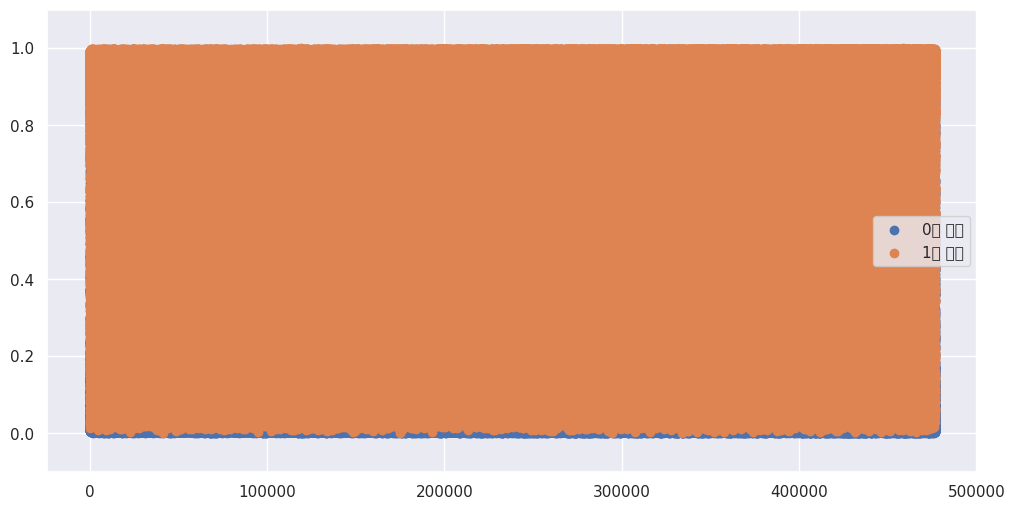

In [82]:
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = best_model.predict_proba(train_X)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()

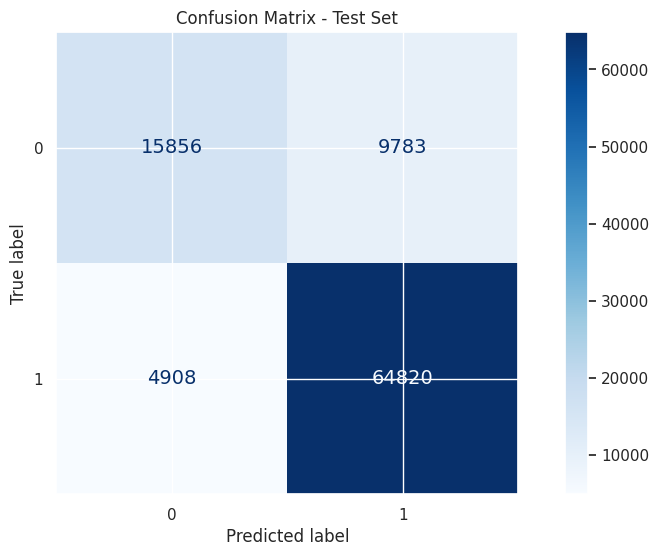

In [83]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. 최종 예측
y_pred = best_model.predict(test_X)

# 2. 혼동 행렬 계산
cm = confusion_matrix(test_y, y_pred)

# 3. 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')  # 'd'는 정수형 표시
plt.title("Confusion Matrix - Test Set")
plt.show()
